In [79]:
import numpy as np
import matplotlib.pyplot as plt
#!pip install scipy
from scipy import stats
from scipy import optimize

### Assumptions of this model:
- ### All the quantities are **fixed** and don't vary with time.
- ### Ad's quality $q_a$ and profit-per-click $v_a$ don't depend on the slot.
- ### Prominence $\lambda_s$ doesn't depend on the ad.

In [80]:
class Auction:
    def __init__(self, *args, **kwargs):
        pass

    def get_winners(self, bids):
        pass

    def get_payments_per_click(self, winners, bids):
        pass

    def round(self, bids):
        winners = self.get_winners(bids) # allocation mechanism!
        payments_per_click = self.get_payments_per_click(winners, bids)
        return winners, payments_per_click

In [81]:
class FirstPriceAuction(Auction):
    def __init__(self, qs):
        self.qs = qs
        self.n_adv = len(self.qs)
    
    def get_winners(self, bids):
        public_values = self.qs*bids
        public_ranking = np.argsort(public_values)
        winner = public_ranking[-1] # <--------------------- The only difference with second price auction implementation
        return winner
    
    def get_payments_per_click(self, winners, bids):
        payment = bids[winners]
        return payment

Let's formalize the dynamics as follows, for each round $t \in [T]$:

1. You choose a bid $b_t \in [0,1]$ at time $t$.
2. The competition's highest bid $m_t$ is realized.
3. If $b_t \geq m_t$, you win and get utility

$$
f_t(b_t) = v - b_t,
$$

and pay a cost equal to the proposed bid $b_t$. Otherwise, both are $0$. We assumed from now on that $q_s*\lambda_s=1$ (CTR=1)

In [82]:
# advertisers' fixed parameters
n_adv = 4 # four advertisers
qs = np.array([1, 1, 1, 1]) # quality scores
v = np.array([0.7, 1.1, 1.4, 0.85]) # valuations
possible_bids_space = np.linspace(0.05, 1, 20) # possible bids space

print(f'Possible bids space: {possible_bids_space}')

assert len(qs) == n_adv
assert len(v) == n_adv

# environmental settings
n_users= 3

auction = FirstPriceAuction(qs=qs)
for u in range(n_users):
    print(f'# User {u}')
    bids = np.random.choice(possible_bids_space, size=n_adv)
    pub_values = bids*qs
    print(f'Bids: {bids}, Publisher Values: {pub_values}')
    winner, payment_per_click = auction.round(bids=bids)
    utility = np.zeros(n_adv)
    utility[winner] = v[winner] - payment_per_click
    print(f'Auction Winner: {winner}, Payment-per-click: {payment_per_click}')
    print(f'Utilities: {utility}')
    print(f'Payment == Bid : {payment_per_click == bids[winner]}')

Possible bids space: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.  ]
# User 0
Bids: [0.6  0.75 0.75 0.9 ], Publisher Values: [0.6  0.75 0.75 0.9 ]
Auction Winner: 3, Payment-per-click: 0.9
Utilities: [ 0.    0.    0.   -0.05]
Payment == Bid : True
# User 1
Bids: [0.5  0.65 0.9  0.65], Publisher Values: [0.5  0.65 0.9  0.65]
Auction Winner: 2, Payment-per-click: 0.9
Utilities: [0.  0.  0.5 0. ]
Payment == Bid : True
# User 2
Bids: [0.9  0.15 0.25 0.8 ], Publisher Values: [0.9  0.15 0.25 0.8 ]
Auction Winner: 0, Payment-per-click: 0.9
Utilities: [-0.2  0.   0.   0. ]
Payment == Bid : True


The idea in the previous code is just showcasing that there 4 bids, therefore i=4, and maken them to play the first price auction and win the ones always who bidf the highest. In this case we are not imposing the case where $b_t>v_i$ for each $i$, so we could get negatives. This is just exploratory.

## Advertiser's Perspective: learning in repeated first price auctions

### We assume from now on that all CTRs are equal to 1
## Stochatic setting

C:\Users\Recup\AppData\Local\Temp\ipykernel_35780\958234372.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


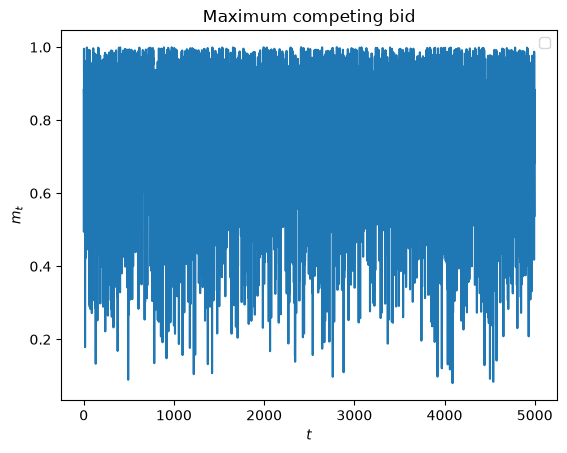

In [83]:
### Stochastic Bidders: my competitors sample their bids from 
### probability distributions

n_advertisers = 3
n_users = 5000 #T-rounds
B = 50
my_valuation = 0.6
rho = B/n_users

# simple scenario: competitors sample bids from a uniform 
other_bids = np.random.uniform(0, 1, size = (n_advertisers, n_users))
# I assume that competitors may have a larger budget than mine, but they may
# not deplete it.
m_t = other_bids.max(axis=0)

plt.title("Maximum competing bid")
plt.plot(m_t)
plt.xlabel('$t$')
plt.ylabel('$m_t$')
plt.legend()
plt.show()

This code generates the realized maximum competing bid for each round.

### When the competing bids are $b_i \sim U([0,1]), i=1,\dots,k$,  the maximum is $m_t \sim Beta(k,1)$. **We will assume this model now.**

Possible bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


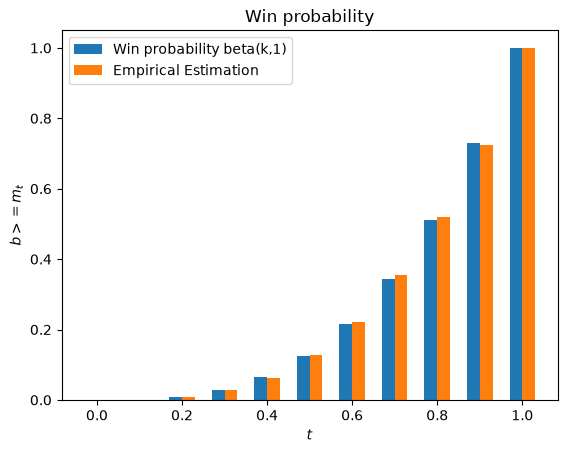

In [84]:
### the maximum among k uniformly distributed r.v.s is a beta r.v. with alpha=k and beta=1
available_bids = np.linspace(0,1,11)
print(f'Possible bids space: {available_bids}')

# This functions recieve a array of possible bids and return the beta(n_advertisers, 1) CDF evaluated 
# at those bids. This is the theoretical win probability of a bid b >= m_t

win_probabilities = stats.beta.cdf(available_bids, n_advertisers, 1)

emp_win_probabilities = np.array([np.sum(b >= m_t) for b in available_bids])/len(m_t)

plt.title("Win probability")
width = 0.03
plt.bar(available_bids -width/2, win_probabilities, width=width, align='center', label='Win probability beta(k,1)')
plt.bar(available_bids +width/2, emp_win_probabilities, width=width, align='center', label='Empirical Estimation')
plt.xlabel('$t$')
plt.ylabel('$b >= m_t$')
plt.legend()
plt.show()

# Without Budget

## What's the baseline (the clairvoyant)?

Without the budget constraint (UCB1 ignoring budget) we will have the (Bernoulli-like) realized reward of playing bid $b$ you get $v-b$ if you win the auction, $0$ otherwise.

$$
r(b) = (v-b)\cdot\mathbb{1}\{b \geq m_t\}
$$

and 
$$
\mu(b) = \mathbb{E}_{m_t}[r(b)] = (v-b)\,\mathbb{P}(b \geq m_t)
$$

is exactly the $\mathbb{E}[f(b)]$. Now lets calculate the optimal arm $b^*$

$$
b^\star \in \arg\max_{b \in \mathcal{B}} \mu(b)
$$

Using appendix proof, we can determine that in this case $F_{\text{Beta}(k,1)}(b) = b^k$. 

**Determine the General Formula for the optimum**


So to estimate the general closed-form solution (continuous bid space $b \in [0,1]$, competing
bids $m_t \sim \text{Beta}(k,1)$, so $\mathbb{P}(b \geq m_t) = b^k$):

$$
\mu(b) =  \mathbb{E}_{m_t}[r(b)] = (v-b)\,\mathbb{P}(b \geq m_t)=(v-b)\,b^k
$$

Differentiate w.r.t. $b$ and set to zero:

$$
\mu'(b) = -b^k + k(v-b)\,b^{k-1} = b^{k-1}\big[k v - (k+1) b\big]
$$

$$
\mu'(b) = 0 \;\;\Longrightarrow\;\; b^\star = \frac{k}{k+1}\,v
$$

(the other root $b=0$ is a minimum, and $\mu'(b)>0$ for $b<b^\star$,
$\mu'(b)<0$ for $b>b^\star$, confirming this is the unique maximum.)

In [85]:
# Continuous optimal bid: b* = k/(k+1) * v
optimal_bid = (n_advertisers / (n_advertisers + 1)) * my_valuation

# Expected reward for every available bid arm
win_probabilities = available_bids ** n_advertisers
expected_rewards = (my_valuation - available_bids) * win_probabilities

print(f'Optimal bid: {optimal_bid:.4f}')

Optimal bid: 0.4500


Now we know the best bid, but since we discretized over some possible arms (possible bids) we need to select the closest one

In [86]:
# Select the arm closest to the continuous optimum
closest_arm_index = np.argmin(np.abs(available_bids - optimal_bid))
closest_arm = available_bids[closest_arm_index]
closest_arm_reward = expected_rewards[closest_arm_index]

print(f"Closest available arm: {closest_arm:.4f}")
print(f"Expected reward for closest arm: {closest_arm_reward:.4f}")


Closest available arm: 0.4000
Expected reward for closest arm: 0.0128


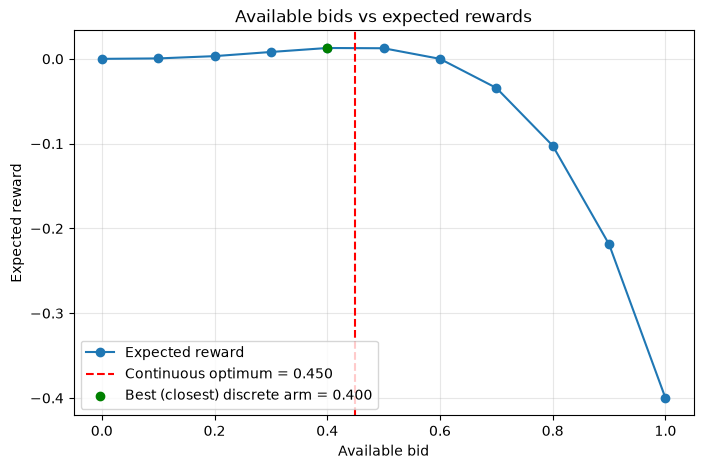

In [87]:
plt.figure(figsize=(8, 5))
plt.plot(available_bids, expected_rewards, marker='o', label='Expected reward')
plt.axvline(optimal_bid, color='red', linestyle='--',
            label=f'Continuous optimum = {optimal_bid:.3f}')
plt.scatter(closest_arm, closest_arm_reward, color='green', zorder=3,
            label=f'Best (closest) discrete arm = {closest_arm:.3f}')
plt.xlabel('Available bid')
plt.ylabel('Expected reward')
plt.title('Available bids vs expected rewards')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Now we implement the UCB Witouth Budget Learner

In [88]:
class UCB1AuctionAgent:
    def __init__(self, available_bids, valuation, T, reward_range=1):
        self.available_bids = np.array(available_bids)
        self.valuation = valuation
        self.K = len(self.available_bids)
        self.T = T
        self.reward_range = reward_range

        self.arm = None
        self.t = 0
        self.N_pulls = np.zeros(self.K)
        self.average_rewards = np.zeros(self.K)

    def pull_arm(self):
        # Explore every arm once
        if self.t < self.K:
            self.arm = self.t
        else:
            confidence_bonus = self.reward_range * np.sqrt(
                2 * np.log(self.T) / self.N_pulls
            )
            ucbs = self.average_rewards + confidence_bonus
            self.arm = np.argmax(ucbs)

        return self.arm

    def update(self, reward):
        self.N_pulls[self.arm] += 1

        self.average_rewards[self.arm] += (
            reward - self.average_rewards[self.arm]
        ) / self.N_pulls[self.arm]

        self.t += 1

In [89]:
# Take good bids only
available_bids = available_bids[available_bids<=my_valuation] # newly added to avoid unnecessary bids

agent = UCB1AuctionAgent(
    available_bids=available_bids,
    valuation=my_valuation,
    T=n_users,
    reward_range=my_valuation # newly added
)

selected_bids = []
observed_rewards = []
payments = []

for t in range(n_users):
    # Select an arm index and obtain the corresponding bid
    arm = agent.pull_arm()
    bid = available_bids[arm]

    # Win if our bid is at least the highest competing bid
    win = bid >= m_t[t]

    # CTR = 1, so reward is valuation minus bid if we win
    reward = (my_valuation - bid) * int(win)
    payments.append(bid*int(win))

    # Update the UCB statistics
    agent.update(reward)

    selected_bids.append(bid)
    observed_rewards.append(reward)

selected_bids = np.array(selected_bids)
observed_rewards = np.array(observed_rewards)

print(f"Number of pulls per arm: {agent.N_pulls}")
print(f"Estimated reward per arm: {agent.average_rewards}")
print(f"Total reward: {observed_rewards.sum():.4f}")

Number of pulls per arm: [720. 742. 771. 821. 997. 949.]
Estimated reward per arm: [0.         0.00134771 0.00311284 0.00584653 0.01384152 0.01190727]
Total reward: 33.3000


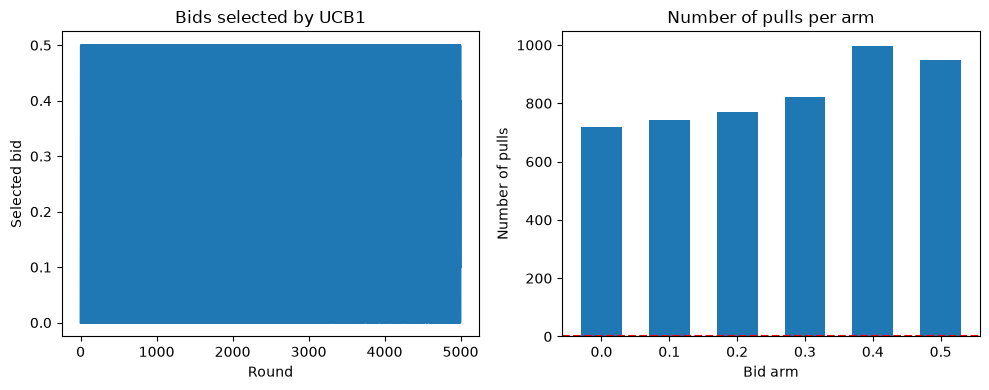

In [90]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(selected_bids)
plt.xlabel("Round")
plt.ylabel("Selected bid")
plt.title("Bids selected by UCB1")

plt.subplot(1, 2, 2)
plt.bar(available_bids, agent.N_pulls, width=0.06)
plt.xlabel("Bid arm")
plt.ylabel("Number of pulls")
plt.title("Number of pulls per arm")

plt.axhline(
    optimal_bid,
    color="red",
    linestyle="--",
    label=f"Continuous optimum = {optimal_bid:.3f}"
)
plt.tight_layout()
plt.show()

We see the bid arm select the closest arms 0.4 and 0.5. So its learning. Now we run different trials

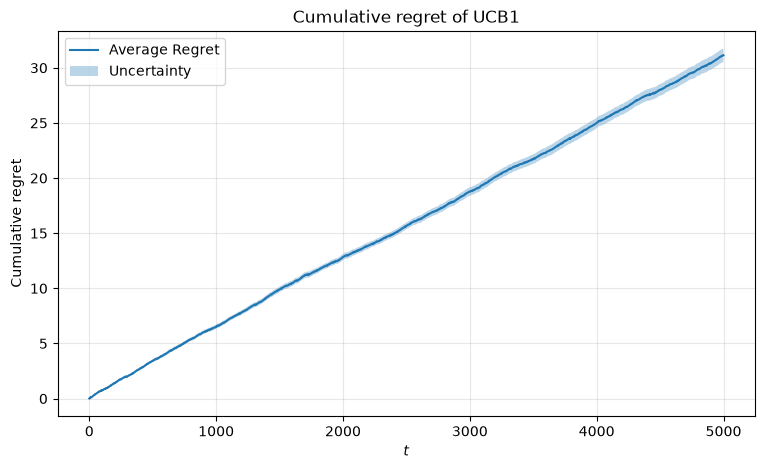

Clairvoyant best bid: 0.40
Average final regret: 31.1333


In [91]:
# Cumulative regret with uncertainty

T = n_users
K = len(available_bids)
k = n_advertisers

n_trials = 30

# Expected reward of each bid arm
win_probabilities = available_bids ** k
expected_rewards = (
    my_valuation - available_bids
) * win_probabilities

# Best discrete arm for the clairvoyant
best_action = np.argmax(expected_rewards)

# Expected clairvoyant reward at every round
expected_clairvoyant_rewards = np.repeat(
    expected_rewards[best_action],
    T
)

regret_per_trial = []

for seed in range(n_trials):
    np.random.seed(seed)

    # Generate competing bids for this trial
    other_bids = np.random.uniform(
        0,
        1,
        size=(k, T)
    )

    # Highest competing bid at every round
    m_t = other_bids.max(axis=0)

    agent = UCB1AuctionAgent(
        available_bids=available_bids,
        valuation=my_valuation,
        T=T
    )

    agent_rewards = np.array([])

    for t in range(T):
        # Select an arm and obtain the corresponding bid
        arm = agent.pull_arm()
        bid = available_bids[arm]

        # Realized auction reward
        win = bid >= m_t[t]
        reward = (my_valuation - bid) * int(win)

        # Update UCB1
        agent.update(reward)

        agent_rewards = np.append(
            agent_rewards,
            reward
        )

    # Cumulative pseudo-regret
    cumulative_regret = np.cumsum(
        expected_clairvoyant_rewards - agent_rewards
    )

    regret_per_trial.append(cumulative_regret)


# Calculating Trial Metrics

regret_per_trial = np.array(regret_per_trial)

# Average regret and uncertainty
average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)
standard_error = regret_sd / np.sqrt(n_trials)

# Plot cumulative regret
time = np.arange(T)

plt.figure(figsize=(9, 5))

plt.plot(
    time,
    average_regret,
    label="Average Regret"
)

plt.fill_between(
    time,
    average_regret - standard_error,
    average_regret + standard_error,
    alpha=0.3,
    label="Uncertainty"
)

plt.xlabel("$t$")
plt.ylabel("Cumulative regret")
plt.title("Cumulative regret of UCB1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(
    f"Clairvoyant best bid: "
    f"{available_bids[best_action]:.2f}"
)

print(
    f"Average final regret: "
    f"{average_regret[-1]:.4f}"
)

<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Recup\AppData\Local\Temp\ipykernel_35780\2873557776.py:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('$\sum c_t$')


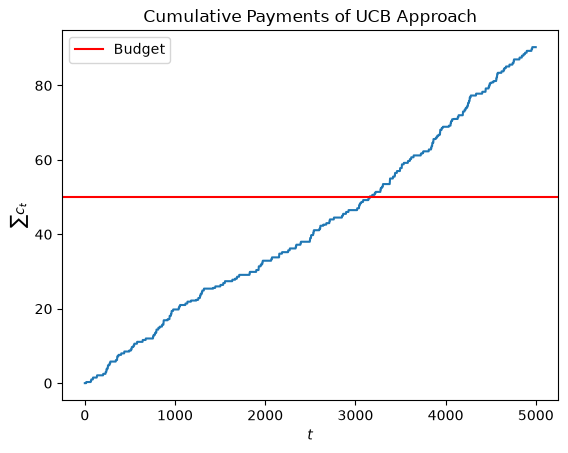

In [92]:
cumulative_payments = np.cumsum(payments)
plt.plot(cumulative_payments)
plt.xlabel('$t$')
plt.ylabel('$\sum c_t$')
plt.axhline(B, color='red', label='Budget')
plt.legend()
plt.title('Cumulative Payments of UCB Approach')
plt.show()

# With Budget


## What's the baseline (the clairvoyant)?

We are in a **stochastic** environment, thus we can use a notion of clairvoyant in **expectation**, i.e., the clairvoyant doesn't know all the actual bids but their distributions only. This clairvoyant is weaker than the one presented for truthful auctions. However, it is allowed to exceed budget (it only satisfies the budget constraint in expectation).

$$ \text{maximize}_{\gamma \in \Delta(B)}~~~ f(\gamma) ~~~ \text{s.t.  } Tc(\gamma) \le B,$$

Noting that $f(\gamma)= \sum_b \gamma(b)(v-b) \mathbb{P}(b\ge m)$, $c(\gamma)= \sum_b \gamma(b)b \mathbb{P}(b\ge m)$ and $\rho = \frac{B}{T}$, and by expliciting the simplex constraints, we get:

$$ \text{maximize}_{\gamma \in \mathbb{R}^K} \quad \sum_b \gamma(b)(v-b)\mathbb{P}(b \ge m) \quad \text{s.t.} \quad \sum_b \gamma(b) b\,\mathbb{P}(b \ge m)\le \rho, $$

$$ \sum_{b} \gamma(b) = 1 $$

$$ 0 \le \gamma(b) \le 1 \quad \forall b $$

This is linear programming (LP)

We can rewrite our optimization problem in matrix form as:  $$\text{minimize}_x ~~cx \quad s.t. ~~~Ax \le a, Bx = b, m \le x \le M$$


In [93]:
## Linear Program
def compute_clairvoyant(available_bids, my_valuation, rho, win_probabilities):
    c = -(my_valuation-available_bids)*win_probabilities
    A_ub = [available_bids*win_probabilities]
    b_ub = [rho]
    A_eq = [np.ones(len(available_bids))]
    b_eq = [1]
    res = optimize.linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0,1))
    gamma = res.x
    
    return gamma, -res.fun, np.sum(available_bids*gamma*win_probabilities)

In [94]:
B = 300
rho = B/n_users

available_bids = np.linspace(0,1,11)
win_probabilities = stats.beta.cdf(available_bids, n_advertisers, 1)

gamma, exp_utility, exp_payment = compute_clairvoyant(available_bids, my_valuation, rho, win_probabilities)

print(f'Budget:{B} valuation:{my_valuation} n_users:{n_users} rho:{rho}')
print(f'available bids ={available_bids}')
print(f'gamma={gamma}')
print(f'expected utility={exp_utility:.2f}, expected payment={exp_payment:.2f}')

Budget:300 valuation:0.6 n_users:5000 rho:0.06
available bids =[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
gamma=[ 0.  0.  0.  0.  1. -0.  0.  0.  0.  0.  0.]
expected utility=0.01, expected payment=0.03


# UCB with Budget Constraint

$$ f(a) \sim D^f(a) $$
$$ c(a) \sim D^c(a) $$
$$ B>0, T>0 (\rho>0) $$

Compute UCBs $f^{\text{UCB}}(b)$ and LCBs $c^{\text{LCB}}(b)$ for every $b \in B$ (using LCBs on the costs means being optimistic!)

Solve the optimization problem:
$$ \text{maximize}_{\gamma \in \Delta(B)}~~~ \sum_b \gamma(b) f^{\text{UCB}}(b) ~~~ \text{s.t.} \sum_b \gamma(b) c^{\text{LCB}}(b) \le \rho,$$

Update with bandit feedback

In [ ]:
# the agent does not need the values of the available bids or the valuation
# the first bid is 0
class UCBLikeAgent():
    def __init__(self, K, B, T, range=1):
        self.K = K
        self.T = T
        self.range = range
        self.a_t = None # it's an index, not the actual bid
        self.avg_f = np.zeros(K)
        self.avg_c = np.zeros(K)
        self.N_pulls = np.zeros(K)
        self.budget = B
        self.rho = B/T
        self.t = 0
    
    def pull_arm(self):
        if self.budget < 1:
            self.a_t = 0
            return 0
        if self.t < self.K:
            self.a_t = self.t 
        else:
            f_ucbs = self.avg_f + self.range*np.sqrt(2*np.log(self.T)/self.N_pulls)
            c_lcbs = self.avg_c - self.range*np.sqrt(2*np.log(self.T)/self.N_pulls)
            gamma_t = self.compute_opt(f_ucbs, c_lcbs)
            self.a_t = np.random.choice(self.K, p=gamma_t)
        return self.a_t

    def _compute_opt(self, f_ucb, c_lcb):
        res = optimize.linprog(-f_ucb, A_ub=[c_lcb], b_ub=[self.rho],
                            A_eq=[np.ones(len(f_ucb))], b_eq=[1],
                            bounds=(0, 1), method="highs")
        gamma = np.clip(res.x, 0, None) if res.success else np.eye(len(f_ucb))[np.argmin(c_lcb)]
        return gamma / gamma.sum()
    
    def update(self, f_t, c_t):
        self.N_pulls[self.a_t] += 1
        self.avg_f[self.a_t] += (f_t - self.avg_f[self.a_t])/self.N_pulls[self.a_t]
        self.avg_c[self.a_t] += (c_t - self.avg_c[self.a_t])/self.N_pulls[self.a_t]
        self.budget -= c_t
        self.t += 1

In [104]:
rho = B/n_users

gamma, expected_clairvoyant_utility, expected_clairvoyant_payment = compute_clairvoyant(available_bids, my_valuation, rho, win_probabilities)
# per round values

print(gamma)

[ 0.  0.  0.  0.  1. -0.  0.  0.  0.  0.  0.]


In [105]:
good_bids = available_bids[available_bids<=my_valuation] # you can remove bids greater than the valuation
# good_bids = available_bids 
agent = UCBLikeAgent(K=len(good_bids), 
                     B=B,
                     T=n_users,
                     range=my_valuation)

auction = FirstPriceAuction(np.ones(n_advertisers+1))

utilities = []
my_bids = []
my_payments = []
total_wins = 0

np.random.seed(17)
other_bids = np.random.uniform(0, 1, size = (n_advertisers, n_users))
m_t = other_bids.max(axis=0)
for u in range(n_users):
    # interaction
    my_bid = available_bids[agent.pull_arm()]
    bids = np.append(my_bid, other_bids[:, u].ravel())
    winners, payments_per_click = auction.round(bids=bids)
    my_win = int(winners==0)
    f_t, c_t = (my_valuation-payments_per_click)*my_win, payments_per_click*my_win
    agent.update(f_t, c_t)
    # logging
    utilities.append(f_t)
    my_bids.append(my_bid)
    my_payments.append(c_t)
    total_wins+=my_win

utilities = np.array(utilities)
my_bids = np.array(my_bids)
my_payments = np.array(my_payments)
print(f'Total # of Wins: {total_wins}')

Total # of Wins: 198


<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Recup\AppData\Local\Temp\ipykernel_35780\441209326.py:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('$\sum c_t$')


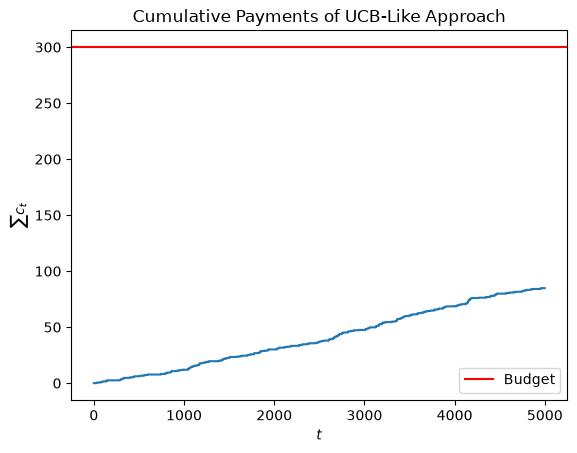

In [106]:
cumulative_payments_1 = np.cumsum(my_payments)
plt.plot(cumulative_payments_1)
plt.xlabel('$t$')
plt.ylabel('$\sum c_t$')
plt.axhline(B, color='red', label='Budget')
plt.legend()
plt.title('Cumulative Payments of UCB-Like Approach')
plt.show()

<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Recup\AppData\Local\Temp\ipykernel_35780\2983216223.py:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('$\sum R_t$')


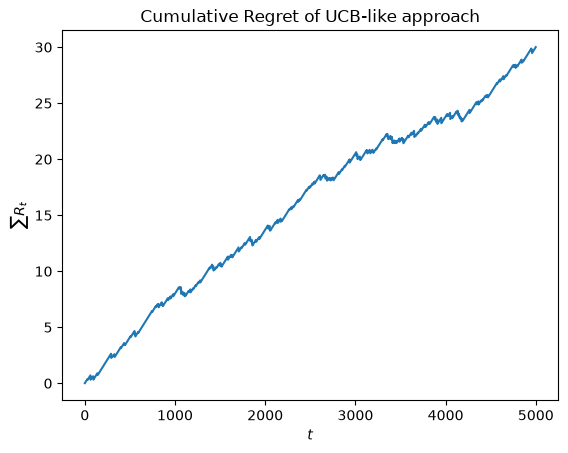

In [107]:
cumulative_regret = np.cumsum(expected_clairvoyant_utility-utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of UCB-like approach')
plt.show()

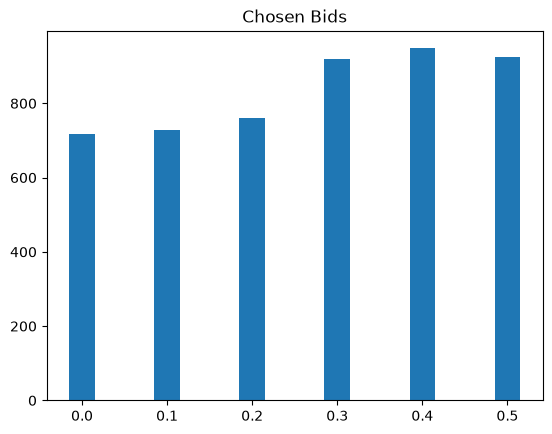

In [108]:
plt.bar(good_bids, agent.N_pulls, width=0.03)
plt.title('Chosen Bids')
plt.show()

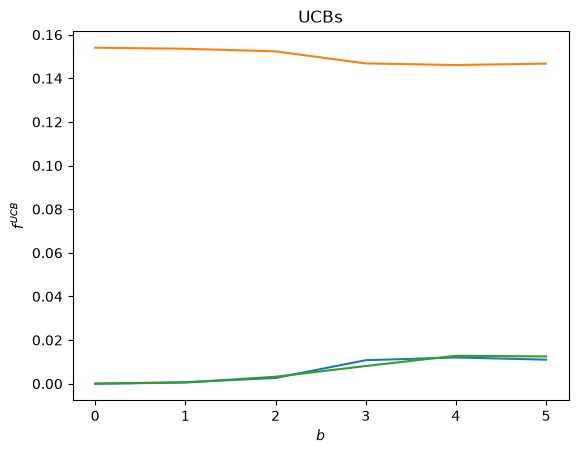

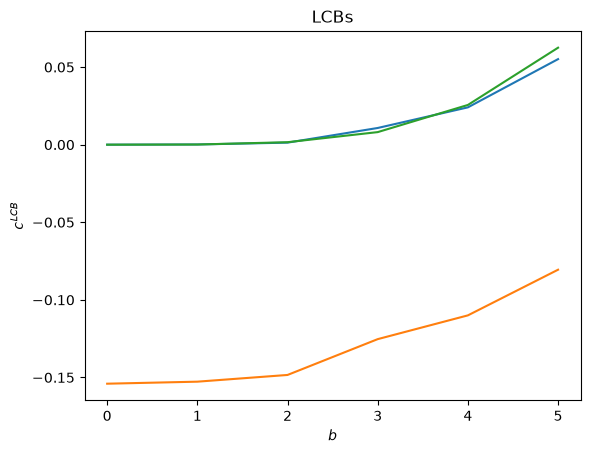

[0.    0.001 0.008 0.027 0.064 0.125 0.216 0.343 0.512 0.729 1.   ]
[718. 729. 760. 920. 948. 925.]
0.05836846131744861


In [109]:
f_ucbs = agent.avg_f + np.sqrt(2*np.log(agent.T)/agent.N_pulls)
c_lcbs = agent.avg_c - np.sqrt(2*np.log(agent.T)/agent.N_pulls)
plt.plot(agent.avg_f, label='est f')
plt.plot(f_ucbs, label='UCB')
plt.plot(win_probabilities[:len(f_ucbs)]*(my_valuation-available_bids[:len(f_ucbs)]), label='est f')
plt.xlabel('$b$')
plt.ylabel('$f^{UCB}$')
plt.title('UCBs')
plt.show()

plt.plot(agent.avg_c)
plt.plot(c_lcbs)
plt.plot(win_probabilities[:len(f_ucbs)]*available_bids[:len(f_ucbs)], label='est f')
plt.xlabel('$b$')
plt.ylabel('$c^{LCB}$')
plt.title('LCBs')
plt.show()

print(win_probabilities)
print(agent.N_pulls)
print(np.sqrt(2*np.log(n_users)/n_users))

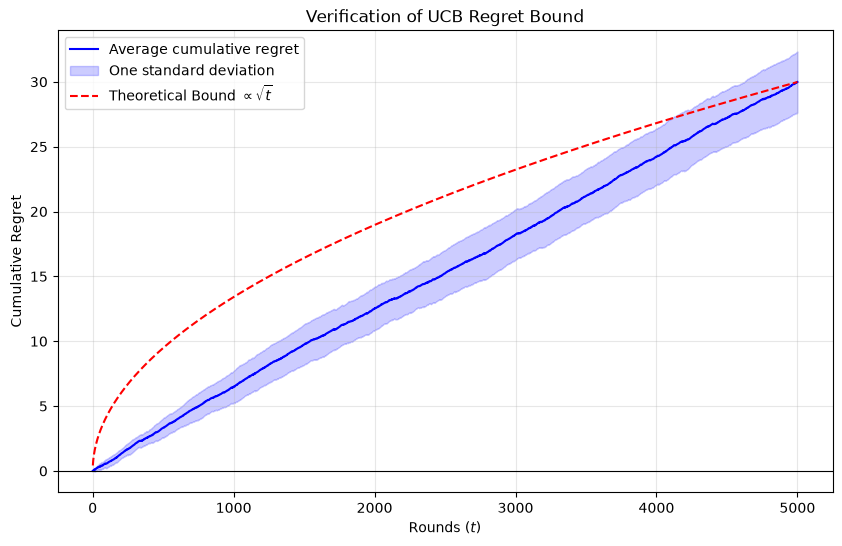

In [110]:
# Cumulative regret of UCB-like approach over multiple trials

n_trials = 30
T = n_users
K = len(good_bids)

regret_per_trial = np.zeros((n_trials, T))
utilities_per_trial = np.zeros((n_trials, T))

for trial in range(n_trials):
    np.random.seed(17 + trial)

    agent_trial = UCBLikeAgent(
        K=K,
        B=B,
        T=T,
        range=my_valuation
    )

    auction_trial = FirstPriceAuction(np.ones(n_advertisers + 1))

    other_bids_trial = np.random.uniform(
        0,
        1,
        size=(n_advertisers, T)
    )

    for t in range(T):
        selected_arm = agent_trial.pull_arm()
        my_bid_trial = good_bids[selected_arm]

        bids_trial = np.append(
            my_bid_trial,
            other_bids_trial[:, t]
        )

        winners_trial, payment_trial = auction_trial.round(
            bids=bids_trial
        )

        my_win_trial = int(winners_trial == 0)

        f_t_trial = (
            my_valuation - payment_trial
        ) * my_win_trial

        c_t_trial = payment_trial * my_win_trial

        agent_trial.update(f_t_trial, c_t_trial)

        utilities_per_trial[trial, t] = f_t_trial

        # Expected clairvoyant utility is the benchmark per round
        regret_per_trial[trial, t] = (
            expected_clairvoyant_utility - f_t_trial
        )

# Cumulative regret for each trial
cumulative_regret_trials = np.cumsum(
    regret_per_trial,
    axis=1
)

# Average and standard deviation across trials
average_cumulative_regret = np.mean(
    cumulative_regret_trials,
    axis=0
)

std_cumulative_regret = np.std(
    cumulative_regret_trials,
    axis=0
)

time = np.arange(1, T + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    time,
    average_cumulative_regret,
    label='Average cumulative regret',
    color='blue'
)

plt.fill_between(
    time,
    average_cumulative_regret - std_cumulative_regret,
    average_cumulative_regret + std_cumulative_regret,
    color='blue',
    alpha=0.2,
    label='One standard deviation'
)

plt.xlabel('$t$')
plt.ylabel('Cumulative regret')
plt.title(
    f'Cumulative Regret of UCB-like Approach '
    f'({n_trials} trials)'
)

plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.grid(alpha=0.3)

C = average_cumulative_regret[-1] / np.sqrt(T)  
plt.plot(time, C * np.sqrt(time), label=r'Theoretical Bound $\propto \sqrt{t}$', linestyle='--', color='red')
plt.title("Verification of UCB Regret Bound")
plt.xlabel("Rounds ($t$)")
plt.ylabel("Cumulative Regret")
plt.legend()
plt.grid(True)
plt.show()

Nice to have:
(iii) Add another case with budget = 20, plot budget vs cumulative payment for UCB without budget. So we could see the difference between with and without budget
(iv) Maybe draw plot of cumulative regret/payment of 2 algorithms in the same plot to compare etc

## Appendix Proof 

Derivation from the Beta PDF. The general Beta$(\alpha,\beta)$ density is

$$
f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}, \qquad x \in [0,1]
$$

where $B(\alpha,\beta) = \dfrac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$. Setting $\beta = 1$:

$$
B(\alpha,1) = \frac{\Gamma(\alpha)\Gamma(1)}{\Gamma(\alpha+1)} = \frac{\Gamma(\alpha)}{\alpha\,\Gamma(\alpha)} = \frac{1}{\alpha}
$$

(using $\Gamma(\alpha+1) = \alpha\Gamma(\alpha)$ and $\Gamma(1)=1$), so the density simplifies to $f(x) = \alpha\, x^{\alpha-1}$. Integrating to get the CDF:

$$
F(x) = \int_0^x \alpha\, t^{\alpha-1}\,dt = x^\alpha
$$

Setting $\alpha = k$ gives exactly $F_{\text{Beta}(k,1)}(b) = b^k$.

<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Recup\AppData\Local\Temp\ipykernel_35780\3860279964.py:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('$\sum c_t$')


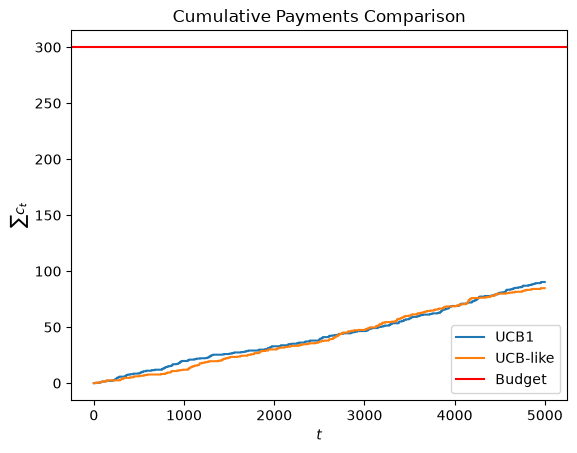

In [111]:
# Archived from this
plt.plot(cumulative_payments, label="UCB1")
plt.plot(cumulative_payments_1, label="UCB-like")
plt.xlabel('$t$')
plt.ylabel('$\sum c_t$')
plt.axhline(B, color='red', label='Budget')
plt.legend()
plt.title('Cumulative Payments Comparison')
plt.show()

